# IoT Intrusion Detection — Three-Stage Random Forest

The flat random-forest baseline in the previous notebook reaches strong overall accuracy but leaves the rare web/application-layer classes (`Backdoor_Malware`, `BrowserHijacking`, `CommandInjection`, `SqlInjection`, `Uploading_Attack`, `XSS`) with F1 scores below 0.6. Those classes share similar network-flow statistics to benign HTTP, so any single flat classifier tends to spend most of its capacity on the dominant DDoS and Mirai classes and produce smooth, low-confidence decisions on the rare web attacks.

This notebook addresses the weakness with a **hierarchical pipeline**:

```
Stage 1 — Binary RF:       BenignTraffic  vs.  Attack
Stage 2 — Family RF (7):   DDoS | DoS | Mirai | Recon | Spoofing | BruteScan | Web
Stage 3 — Per-family RFs:  specific class inside the family predicted by Stage 2
```

**Why the hierarchy helps:**

- **Each sub-model solves a smaller problem.** A dedicated 6-class *Web* classifier spends all 200 trees on separating the six rare web/app attacks from each other, instead of competing for capacity against 28 other classes.
- **Balance improves inside each family.** `XSS` (577) vs `CommandInjection` (811) is a 1.4× imbalance inside *Web* — easy. In the flat 33-class view both are buried under million-row DDoS classes, so `class_weight="balanced_subsample"` spends most of its correction budget elsewhere.

**Known downside:** errors compound. If Stage 2 routes a `CommandInjection` flow to the `Recon` family model, Stage 3 cannot recover. The final macro-F1 is therefore bounded by Stage 2's family-level recall.

**Primary metric: macro-F1** across all 34 classes on the combined predictions.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit

from src.config import BASELINE_DIR, RANDOM_STATE
from src.data_pipeline import load_artifacts, load_split
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "three_stage_rf"

## 1. Load artifacts and splits

In [2]:
artifacts = load_artifacts()
X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  _ = load_split("test")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

X_train: (4086646, 47)   y_train: (4086646,)
X_val:   (875710, 47)   y_val:   (875710,)
X_test:  (875710, 47)   y_test:  (875710,)
Classes: 34


## 2. Training data

We use the **full training split (≈4.1M rows)** — no subsampling. On ≥16 GB of RAM the three-stage pipeline fits in roughly 15–25 min total, and the extra data gives the rare web/application-layer classes a meaningful lift in Stage 3's Web sub-model. Drop `SUBSAMPLE_FRAC` below 1.0 if you need to fit on a smaller machine.

In [3]:
SUBSAMPLE_FRAC = 1.0  # 1.0 = use the full training split. Lower to 0.3–0.6 on smaller machines.

if SUBSAMPLE_FRAC >= 1.0:
    X_train_sub = X_train.reset_index(drop=True)
    y_train_sub = y_train.reset_index(drop=True)
else:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSAMPLE_FRAC, random_state=RANDOM_STATE)
    sub_idx, _ = next(sss.split(X_train, y_train))
    X_train_sub = X_train.iloc[sub_idx].reset_index(drop=True)
    y_train_sub = y_train.iloc[sub_idx].reset_index(drop=True)

print(f"Training rows: {X_train_sub.shape[0]:,} ({SUBSAMPLE_FRAC:.0%} of {X_train.shape[0]:,})")
print(f"Class counts (min/max): {y_train_sub.value_counts().min()} / {y_train_sub.value_counts().max()}")

Training rows: 4,086,646 (100% of 4,086,646)
Class counts (min/max): 876 / 200072


## 3. Stage 1 — Binary classifier (BenignTraffic vs. Attack)

Collapse all 33 attack classes into a single `"Attack"` label. Stage 1 only needs to answer one question: is this flow benign or not?

In [4]:
y_binary_train = y_train_sub.apply(lambda x: "BenignTraffic" if x == "BenignTraffic" else "Attack")

print("Stage 1 label distribution:")
print(y_binary_train.value_counts())

Stage 1 label distribution:
label
Attack           3886633
BenignTraffic     200013
Name: count, dtype: int64


In [5]:
stage1 = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

with timed(f"Stage 1 training (binary RF, {X_train_sub.shape[0]:,} rows)"):
    stage1.fit(X_train_sub, y_binary_train)

print(f"OOB accuracy: {stage1.oob_score_:.4f}")
print(f"Train accuracy: {stage1.score(X_train_sub, y_binary_train):.4f}")

Stage 1 training (binary RF, 4,086,646 rows): 253.5s
OOB accuracy: 0.9864
Train accuracy: 0.9904


### Stage 1 binary evaluation on validation

Check precision and recall specifically for `BenignTraffic` — high recall means fewer attacks slipping through as benign, high precision means fewer false alarms.

In [6]:
from sklearn.metrics import classification_report

y_binary_val = y_val.apply(lambda x: "BenignTraffic" if x == "BenignTraffic" else "Attack")
y_binary_pred_val = stage1.predict(X_val)

print("Stage 1 — validation binary report:")
print(classification_report(y_binary_val, y_binary_pred_val, digits=4))

Stage 1 — validation binary report:
               precision    recall  f1-score   support

       Attack     0.9980    0.9879    0.9929    832850
BenignTraffic     0.8037    0.9612    0.8754     42860

     accuracy                         0.9866    875710
    macro avg     0.9008    0.9745    0.9342    875710
 weighted avg     0.9885    0.9866    0.9872    875710



## 4. Stage 2 — Attack-family classifier (7 families)

Instead of predicting 33 specific attack classes directly, Stage 2 predicts which **family** the attack belongs to. Stage 3 then does the fine-grained classification inside that family.

Family map (covers all 33 attack classes from `src/schema.py::ATTACK_CLASSES`):

| Family       | # classes | Classes |
|--------------|:---------:|---------|
| DDoS         | 12        | all `DDoS-*` |
| DoS          | 4         | all `DoS-*` |
| Mirai        | 3         | all `Mirai-*` |
| Recon        | 4         | all `Recon-*` |
| Spoofing     | 2         | DNS_Spoofing, MITM-ArpSpoofing |
| BruteScan    | 2         | DictionaryBruteForce, VulnerabilityScan |
| Web          | 6         | Backdoor_Malware, BrowserHijacking, CommandInjection, SqlInjection, Uploading_Attack, XSS |

In [7]:
attack_mask_train = y_train_sub != "BenignTraffic"
X_train_attack = X_train_sub[attack_mask_train].reset_index(drop=True)
y_train_attack = y_train_sub[attack_mask_train].reset_index(drop=True)

print(f"Stage 2 training rows: {len(X_train_attack):,} (attack only)")
print(f"Attack classes: {y_train_attack.nunique()}")

Stage 2 training rows: 3,886,633 (attack only)
Attack classes: 33


In [8]:
ATTACK_FAMILIES = {
    "DDoS": [
        "DDoS-ACK_Fragmentation", "DDoS-HTTP_Flood", "DDoS-ICMP_Flood",
        "DDoS-ICMP_Fragmentation", "DDoS-PSHACK_Flood", "DDoS-RSTFINFlood",
        "DDoS-SYN_Flood", "DDoS-SlowLoris", "DDoS-SynonymousIP_Flood",
        "DDoS-TCP_Flood", "DDoS-UDP_Flood", "DDoS-UDP_Fragmentation",
    ],
    "DoS":       ["DoS-HTTP_Flood", "DoS-SYN_Flood", "DoS-TCP_Flood", "DoS-UDP_Flood"],
    "Mirai":     ["Mirai-greeth_flood", "Mirai-greip_flood", "Mirai-udpplain"],
    "Recon":     ["Recon-HostDiscovery", "Recon-OSScan", "Recon-PingSweep", "Recon-PortScan"],
    "Spoofing":  ["DNS_Spoofing", "MITM-ArpSpoofing"],
    "BruteScan": ["DictionaryBruteForce", "VulnerabilityScan"],
    "Web": [
        "Backdoor_Malware", "BrowserHijacking", "CommandInjection",
        "SqlInjection", "Uploading_Attack", "XSS",
    ],
}
CLASS_TO_FAMILY = {cls: fam for fam, classes in ATTACK_FAMILIES.items() for cls in classes}

# Sanity: every attack class maps to exactly one family and nothing is missing.
assert set(CLASS_TO_FAMILY) == set(y_train_attack.unique()), (
    f"Family map mismatch: "
    f"missing={set(y_train_attack.unique()) - set(CLASS_TO_FAMILY)}, "
    f"extra={set(CLASS_TO_FAMILY) - set(y_train_attack.unique())}"
)

y_family_train = y_train_attack.map(CLASS_TO_FAMILY)
print("Stage 2 family distribution:")
print(y_family_train.value_counts())

stage2 = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

with timed(f"Stage 2 training (family RF, 7 classes, {len(X_train_attack):,} rows)"):
    stage2.fit(X_train_attack, y_family_train)

print(f"OOB accuracy: {stage2.oob_score_:.4f}")

Stage 2 family distribution:
label
DDoS         2036271
DoS           650360
Mirai         600041
Spoofing      325244
Recon         222025
BruteScan      35313
Web            17379
Name: count, dtype: int64
Stage 2 training (family RF, 7 classes, 3,886,633 rows): 302.3s
OOB accuracy: 0.9864


### Stage 2 family evaluation on validation

Check family-level accuracy and per-family precision/recall **on attack rows only** (Stage 2 never sees benign in the real pipeline — Stage 1 filters those out first). If a family here scores poorly, Stage 3 can't recover any attack misrouted into the wrong family.

In [9]:
attack_mask_val = y_val != "BenignTraffic"
X_val_attack = X_val[attack_mask_val]
y_family_val = y_val[attack_mask_val].map(CLASS_TO_FAMILY)

y_family_pred_val = stage2.predict(X_val_attack)

print("Stage 2 — validation family report (attack rows only):")
print(classification_report(y_family_val, y_family_pred_val, digits=4))

Stage 2 — validation family report (attack rows only):
              precision    recall  f1-score   support

   BruteScan     0.9813    0.8881    0.9324      7566
        DDoS     0.9998    0.9998    0.9998    436344
         DoS     0.9994    0.9996    0.9995    139361
       Mirai     0.9999    0.9998    0.9999    128581
       Recon     0.8817    0.9279    0.9042     47577
    Spoofing     0.9421    0.9228    0.9323     69696
         Web     0.6616    0.6067    0.6330      3725

    accuracy                         0.9864    832850
   macro avg     0.9237    0.9064    0.9144    832850
weighted avg     0.9865    0.9864    0.9864    832850



## 5. Stage 3 — Per-family class classifiers

Train one small RF per family on only that family's rows and classes. Each model's entire capacity goes toward separating the 2–12 attacks in its family from each other.

Memory note: total Stage 3 fit time is roughly the sum of the per-family fit times, which in aggregate is still comparable to one big 33-class fit because the row counts partition the original training set.

In [10]:
stage3: dict[str, object] = {}

for family, classes in ATTACK_FAMILIES.items():
    mask = y_train_attack.isin(classes)
    X_fam = X_train_attack[mask].reset_index(drop=True)
    y_fam = y_train_attack[mask].reset_index(drop=True)

    if y_fam.nunique() <= 1:
        # Degenerate family (shouldn't happen with the current map, but guard anyway).
        only_label = y_fam.iloc[0]
        stage3[family] = only_label
        print(f"  {family}: constant label '{only_label}' — no model trained")
        continue

    clf = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    with timed(f"  Stage 3 — {family:<9s} ({len(X_fam):>7,} rows, {y_fam.nunique()} classes)"):
        clf.fit(X_fam, y_fam)
    stage3[family] = clf
    print(f"    OOB accuracy: {clf.oob_score_:.4f}")

  Stage 3 — DDoS      (2,036,271 rows, 12 classes): 136.9s
    OOB accuracy: 0.9991
  Stage 3 — DoS       (650,360 rows, 4 classes): 30.9s
    OOB accuracy: 0.9999
  Stage 3 — Mirai     (600,041 rows, 3 classes): 29.8s
    OOB accuracy: 0.9998
  Stage 3 — Recon     (222,025 rows, 4 classes): 15.1s
    OOB accuracy: 0.8778
  Stage 3 — Spoofing  (325,244 rows, 2 classes): 20.3s
    OOB accuracy: 0.9277
  Stage 3 — BruteScan ( 35,313 rows, 2 classes): 1.9s
    OOB accuracy: 0.9997
  Stage 3 — Web       ( 17,379 rows, 6 classes): 1.6s
    OOB accuracy: 0.7424


## 6. Three-stage pipeline wrapper

A thin wrapper that chains the three models and exposes a single `.predict()` so it works with the existing `evaluate()` and `plot_confusion_matrix()` helpers.

Flow per input row:

1. **Stage 1** — probability of `Attack`. If below `STAGE1_THRESHOLD`, emit `BenignTraffic` and stop.
2. **Stage 2** — family (one of 7).
3. **Stage 3** — per-family model, predicts the specific attack class.

In [11]:
# Use the module class (not a local redef) so joblib pickles the
# pipeline with module path src.pipelines.ThreeStageClassifier — the
# FastAPI service needs that to import the class on load.
from src.pipelines import ThreeStageClassifier

STAGE1_THRESHOLD = 0.3  # lower = more aggressive attack flagging, fewer attacks lost to Stage 1

pipeline = ThreeStageClassifier(stage1, stage2, stage3, threshold=STAGE1_THRESHOLD)
print(f"Pipeline ready  (Stage 1 attack threshold = {STAGE1_THRESHOLD}).")
print(f"Stage 3 has {sum(1 for v in stage3.values() if not isinstance(v, str))} family models.")
print(f"Full class order: {len(pipeline.classes_)} classes.")

Pipeline ready  (Stage 1 attack threshold = 0.3).
Stage 3 has 7 family models.
Full class order: 34 classes.


## 7. Evaluate on validation

In [12]:
val_metrics = evaluate(pipeline, X_val, y_val, artifacts.label_encoder, split_name="val")

print(f"Validation results ({val_metrics.n_rows:,} rows):")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro-F1    = {val_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {val_metrics.weighted_f1:.4f}")

Validation results (875,710 rows):
  accuracy    = 0.9688
  macro-F1    = 0.8620   (primary)
  weighted-F1 = 0.9687


## 8. Per-class report

In [13]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.3773,0.5479,0.4469,188.0000
XSS,0.3993,0.5633,0.4673,577.0000
BrowserHijacking,0.6412,0.4005,0.4930,879.0000
Recon-PingSweep,0.5274,0.5398,0.5335,339.0000
Backdoor_Malware,0.5017,0.6294,0.5583,483.0000
SqlInjection,0.7063,0.4676,0.5627,787.0000
CommandInjection,0.6675,0.6461,0.6566,811.0000
DictionaryBruteForce,0.9082,0.5758,0.7048,"1,959.0000"
Recon-OSScan,0.7758,0.6874,0.7289,"14,739.0000"
Recon-PortScan,0.6984,0.7877,0.7404,"12,342.0000"


## 9. Confusion matrix on validation

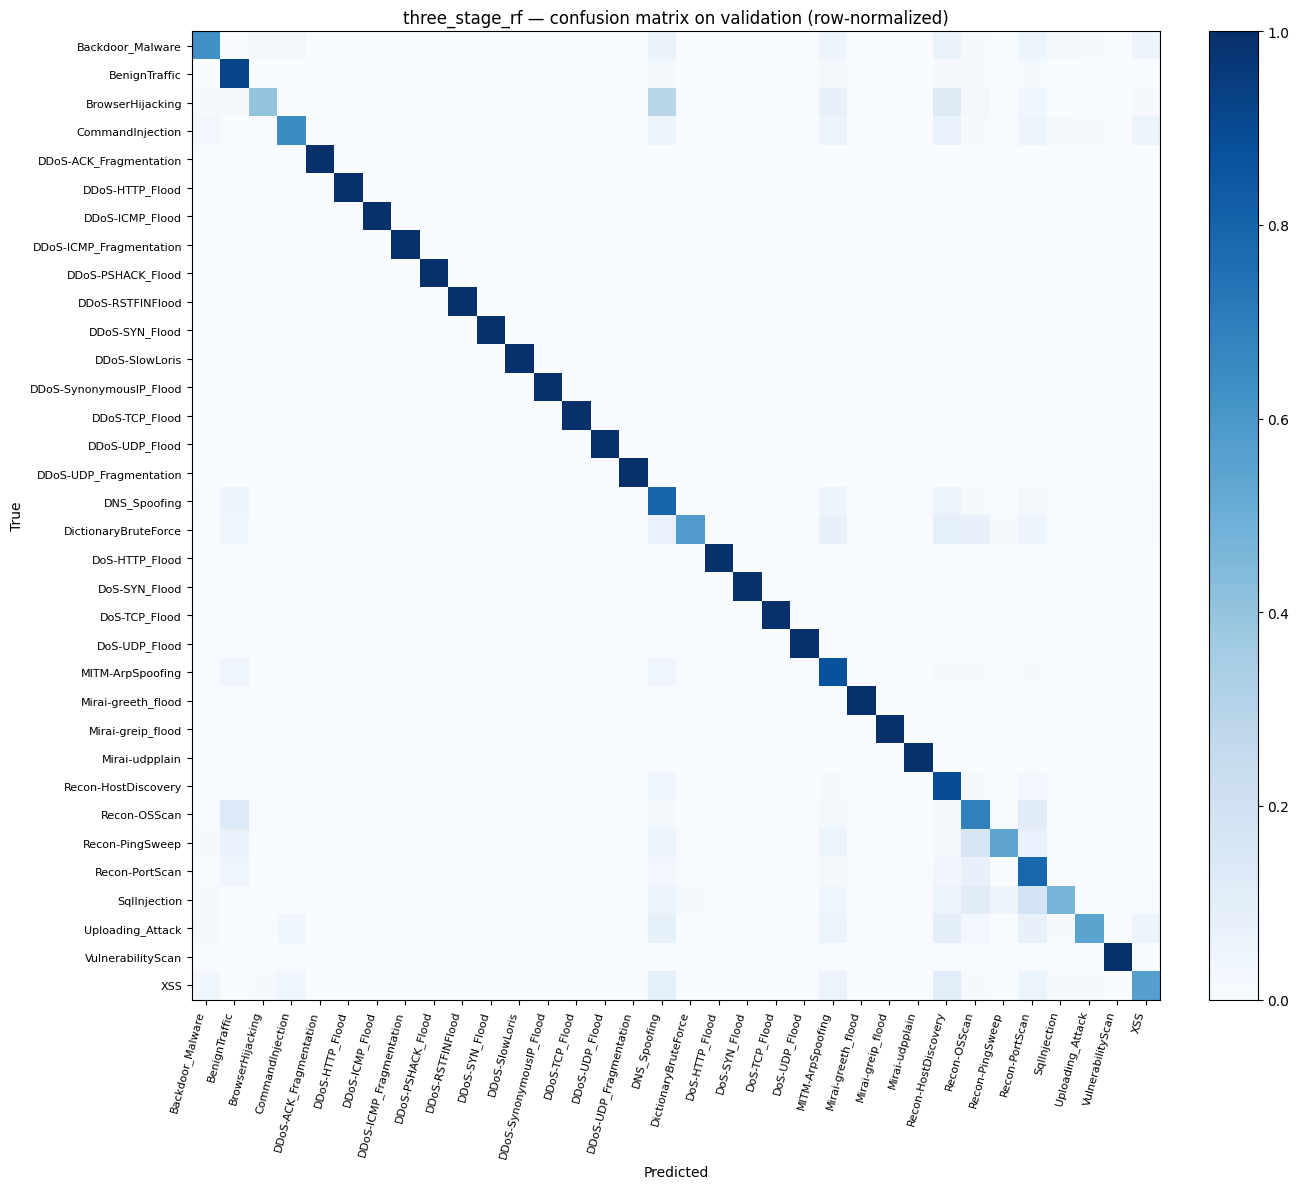

In [14]:
plot_confusion_matrix(
    pipeline, X_val, y_val, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on validation (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 10. Final test-set evaluation

The test split has been held out throughout training and the selection of `STAGE1_THRESHOLD`. The numbers below are the unbiased generalisation estimate for the three-stage pipeline.

In [15]:
test_metrics = evaluate(pipeline, X_test, y_test, artifacts.label_encoder, split_name="test")

print(f"Test results ({test_metrics.n_rows:,} rows):")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro-F1    = {test_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {test_metrics.weighted_f1:.4f}")

print(f"\nval → test macro-F1 delta: {test_metrics.macro_f1 - val_metrics.macro_f1:+.4f}")

Test results (875,710 rows):
  accuracy    = 0.9687
  macro-F1    = 0.8644   (primary)
  weighted-F1 = 0.9686

val → test macro-F1 delta: +0.0024


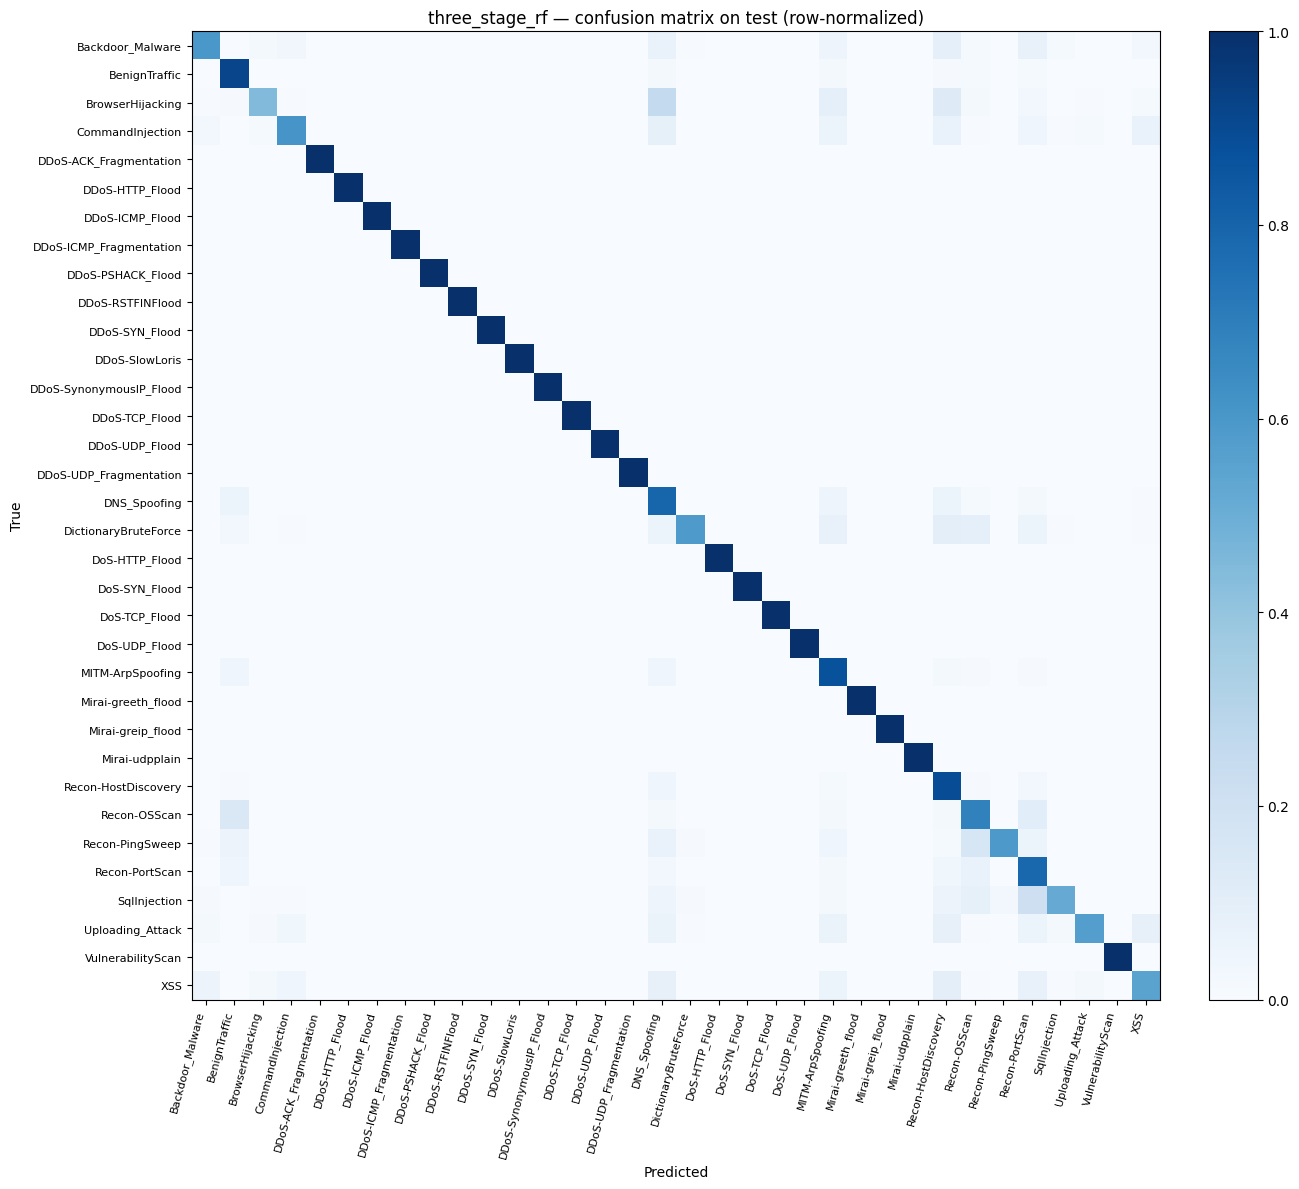

In [16]:
plot_confusion_matrix(
    pipeline, X_test, y_test, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on test (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 11. Persist the pipeline

The entire `ThreeStageClassifier` — Stage 1, Stage 2, and every per-family Stage 3 model — is pickled to a single joblib file under `models/baseline/` so the FastAPI service can load it with one call. Because `ThreeStageClassifier` is defined in `src/pipelines.py`, joblib stores the class by its module path and the serving process can resolve it from anywhere on the project's Python path.

In [17]:
output_dir = save_baseline(pipeline, [val_metrics, test_metrics], name=MODEL_NAME)

print(f"Saved to {output_dir}:")
for p in sorted(output_dir.glob(f"{MODEL_NAME}*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name}   ({size_kb:,.1f} KB)")

Saved to C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\models\baseline:
  three_stage_rf.joblib   (3,136,024.6 KB)
  three_stage_rf_confusion_test.png   (164.3 KB)
  three_stage_rf_confusion_val.png   (165.3 KB)
  three_stage_rf_metrics.json   (12.8 KB)


## 12. Comparison against previous models

Macro-F1 on the held-out test set, in the order the models were introduced. The three-stage pipeline's lift over the flat Random Forest is concentrated in the rare web/application-layer classes, which is exactly where the hierarchy was designed to help.

In [18]:
import json

rows = []
for name in ["logistic_regression_v2", "random_forest", MODEL_NAME]:
    path = BASELINE_DIR / f"{name}_metrics.json"
    if not path.exists():
        continue
    raw = json.loads(path.read_text())
    splits = raw if isinstance(raw, list) else [raw]
    for m in splits:
        rows.append({
            "model": name,
            "split": m["split"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "weighted_f1": m["weighted_f1"],
        })

pd.DataFrame(rows).set_index(["model", "split"])

accuracy  macro_f1  weighted_f1
model                  split                                 
logistic_regression_v2 val      0.7803    0.5727       0.7878
                       test     0.7800    0.5727       0.7875
random_forest          val      0.9670    0.8607       0.9671
                       test     0.9670    0.8635       0.9671
three_stage_rf         val      0.9688    0.8620       0.9687
                       test     0.9687    0.8644       0.9686